# **Fine Timing**
## Learning Objectives
This notebook is to walk the reader through the process of determining the relative time drifts between all antenna for a single satellite pass. The emphasis is on elaborating on each step so as to improve understanding facilitate further work on this process. The production code for fine timing is essentially a more efficient and streamlined version of this exact workflow, meaning all actual analytical and data processing decisions are outlined below.

## Prerequisites
This notebook assumes an understanding of how we store data, the specifics of our timing problems, but also the basics of signal processing. Some useful concepts include filter banks, beamforming, time correlations, and the relationship between time delays and visibility phasing.

In [1]:
#system
import os
import sys
sys.path.insert(0, "/home/thomasb/")
#general
import numpy as np 
import numba as nb
import time
import importlib
import json
import argparse
import h5py
from matplotlib import pyplot as plt
from datetime import datetime as dt
#utils
from albatros_analysis.src.correlations import baseband_data_classes as bdc
from albatros_analysis.src.utils import baseband_utils as butils
from albatros_analysis.src.utils import orbcomm_utils as outils
from albatros_analysis.src.utils import finetiming_utils as futils
from albatros_analysis.scripts.mapmaking import rfitools
#helpers and functions
from scipy.optimize import minimize,check_grad,least_squares
from scipy.ndimage import median_filter
from scipy.ndimage import binary_opening, binary_closing, label
from skyfield.api import load, wgs84
#etc

sys.path.append(os.path.expanduser('~'))
importlib.reload(futils)

BDC is using numpy
BDC is using numpy


<module 'albatros_analysis.src.utils.finetiming_utils' from '/home/thomasb/albatros_analysis/src/utils/finetiming_utils.py'>

## 1. Setup
The first step is to determine what batch we want to look at. We select the corresponding config file and extract all the relavant information. More information on how the config file system works can be found [here](/pipeline/data_structure/).

In [2]:
path_config = "/home/thomasb/albatros_analysis/scripts/orbcomm/config/nov25_batch_1762272160.json"

with open(path_config, "r") as f:
    config = json.load(f)
antpos=[]
for i, (ant, details) in enumerate(config["antennas"].items()):
    antpos.append(details["coordinates"])
print(antpos)

batch_start_ts = config["correlation"]["start_timestamp"]
batch_end_ts = config["correlation"]["end_timestamp"]
osamp = config['correlation']['osamp']
acclen = config['correlation']['new_acclen']

print(acclen)

T_SPECTRA = 4096/250e6 * osamp
print(T_SPECTRA)

[[79.41719805, -90.75873919, 183.0684], [79.38845641, -91.01920296, 25.1938], [79.41830257, -90.66739545, 59.6242], [79.39798424, -90.79984241, 41.699], [79.41147412, -90.69526613, 31.6314], [79.44375769, -90.71820263, 414.9131]]
1024
0.001048576


Next, we go into the batch's data directory to recover what satellites passes we have at our disposition, and to check what the UTC mapping looks like for that batch.

In [3]:
path_batch = f'/scratch/thomasb/batch_{batch_start_ts}'

path_pulses = os.path.join(path_batch, "data/pulses.json")
with open(path_pulses, "r") as f:
        pulse_list = json.load(f)

path_map = os.path.join(path_batch, 'timing_discrepancies/times_all.json')
with open(path_map, "r") as f:
        map_dict = json.load(f)

In [4]:
antmap = {0:"MARS2", 1:"MARS4",2:"MARS5",3:"MARS6",4:"MARS7",5:"MARS8"}
ant_idxs = [0, 1, 2, 3, 4, 5]
nant = len(ant_idxs)
nblines = len(ant_idxs)*(len(ant_idxs)-1)//2

We then decide on a satellite pass, and load in the relevant information. This includes the start and end times, detected satellite, and detection channel. We also determine the file name for the pass' data, and the spectrum number that corresponds to the start of this data.

In [5]:
idx_pulse = 2

#extract from pulses json
pulse = pulse_list[idx_pulse]
print(pulse)

pulse_start_ts = pulse['t_start']
pulse_end_ts = pulse['t_end']
satID = pulse['sat']
chan_det = pulse['channel']
print('detection channel', chan_det)

pulse_start_spec = pulse['start_specnum']
print(pulse_start_spec)

assert satID in {59051, 57166}

if chan_det%2 == 0:
    chans_old = np.arange(chan_det-2, chan_det+2) + 1834
else:
    chans_old = np.arange(chan_det-1, chan_det+3) + 1834

print(chans_old)

#double check if it's centered on the channel or not!
new_chans = np.linspace(chans_old[0], chans_old[-1]+1, osamp*len(chans_old), endpoint=False) 
freqs_all = 250e6 - new_chans*250e6/4096
print(freqs_all[0])

{'antenna': 'MARS7', 'sat': 57166, 'channel': 3, 't_start': 1762280390, 't_end': 1762280684, 'len': 294, 'missing': ['MARS3'], 'start_specnum': 505621955}
detection channel 3
505621955
[1836 1837 1838 1839]
137939453.125


We use the starting spectrum to correct the pulse starting time to the correct actual UTC time at which it was observed. For more information on why this is necessary, or how we know the appropriate correction, see the [UTC Timing Page](/pipeline/utc/).

In [6]:
UTC_per_spec = map_dict['fit']['UTC_per_spec']
UTC_offset = map_dict['fit']['UTC_offset']
print('UTC per spec', UTC_per_spec)
print('UTC offset', UTC_offset)

pstart1 = UTC_per_spec*pulse_start_spec + UTC_offset
print(pstart1)

tle_path = outils.get_tle_file(pstart1, "/project/rrg-sievers/mohanagr/OCOMM_TLES")

UTC per spec 1.638401223564929e-05
UTC offset 1762272106.089236
1762280390.2055333


## 2. Getting Clean Visibilities
We now load in the satellite pass data.

In [ ]:
fname_data = f"data_raw_osamp=64_start={pulse_start_ts}_end={pulse_end_ts}_chans={chans_old[0]}:{chans_old[-1]}.npy"
data1 = np.load(os.path.join(path_batch, 'data', fname_data))
print('size in GB', data1.nbytes/(1024**3))
print('nants, npols, ntimes, nchans', data1.shape)

Once we have the raw data, with the correponding times, frequencies, and satellite ID, we compute the beamformed visibilities. This is done to remove the satellite's phase and isolate any clock drifts.


In [ ]:
importlib.reload(futils)
#get beamformed visibilities
vis1 = futils.get_vis(data1,satID,freqs_all,pstart1,pulse_end_ts,antpos,ant_idxs,tle_path,T_SPECTRA,acclen)

vis shape (15, 273, 256)
catalog #57166 epoch 2025-11-04 23:02:29 UTC
one delay prediction: 0.07293891906738281
done 0 1 .Processed 1 baselines
catalog #57166 epoch 2025-11-04 23:02:29 UTC
one delay prediction: 0.06384849548339844
done 0 2 .Processed 2 baselines
catalog #57166 epoch 2025-11-04 23:02:29 UTC
one delay prediction: 0.06391406059265137
done 0 3 .Processed 3 baselines
catalog #57166 epoch 2025-11-04 23:02:29 UTC
one delay prediction: 0.06948494911193848
done 0 4 .Processed 4 baselines
catalog #57166 epoch 2025-11-04 23:02:29 UTC
one delay prediction: 0.11834025382995605
done 0 5 .Processed 5 baselines
catalog #57166 epoch 2025-11-04 23:02:29 UTC
one delay prediction: 0.06437516212463379
done 1 2 .Processed 6 baselines
catalog #57166 epoch 2025-11-04 23:02:29 UTC
one delay prediction: 0.0815126895904541
done 1 3 .Processed 7 baselines
catalog #57166 epoch 2025-11-04 23:02:29 UTC
one delay prediction: 0.07133889198303223
done 1 4 .Processed 8 baselines
catalog #57166 epoch 202

To get an idea of what the satellite signal is looking like, we plot the visibility amplitude over time and frequency.

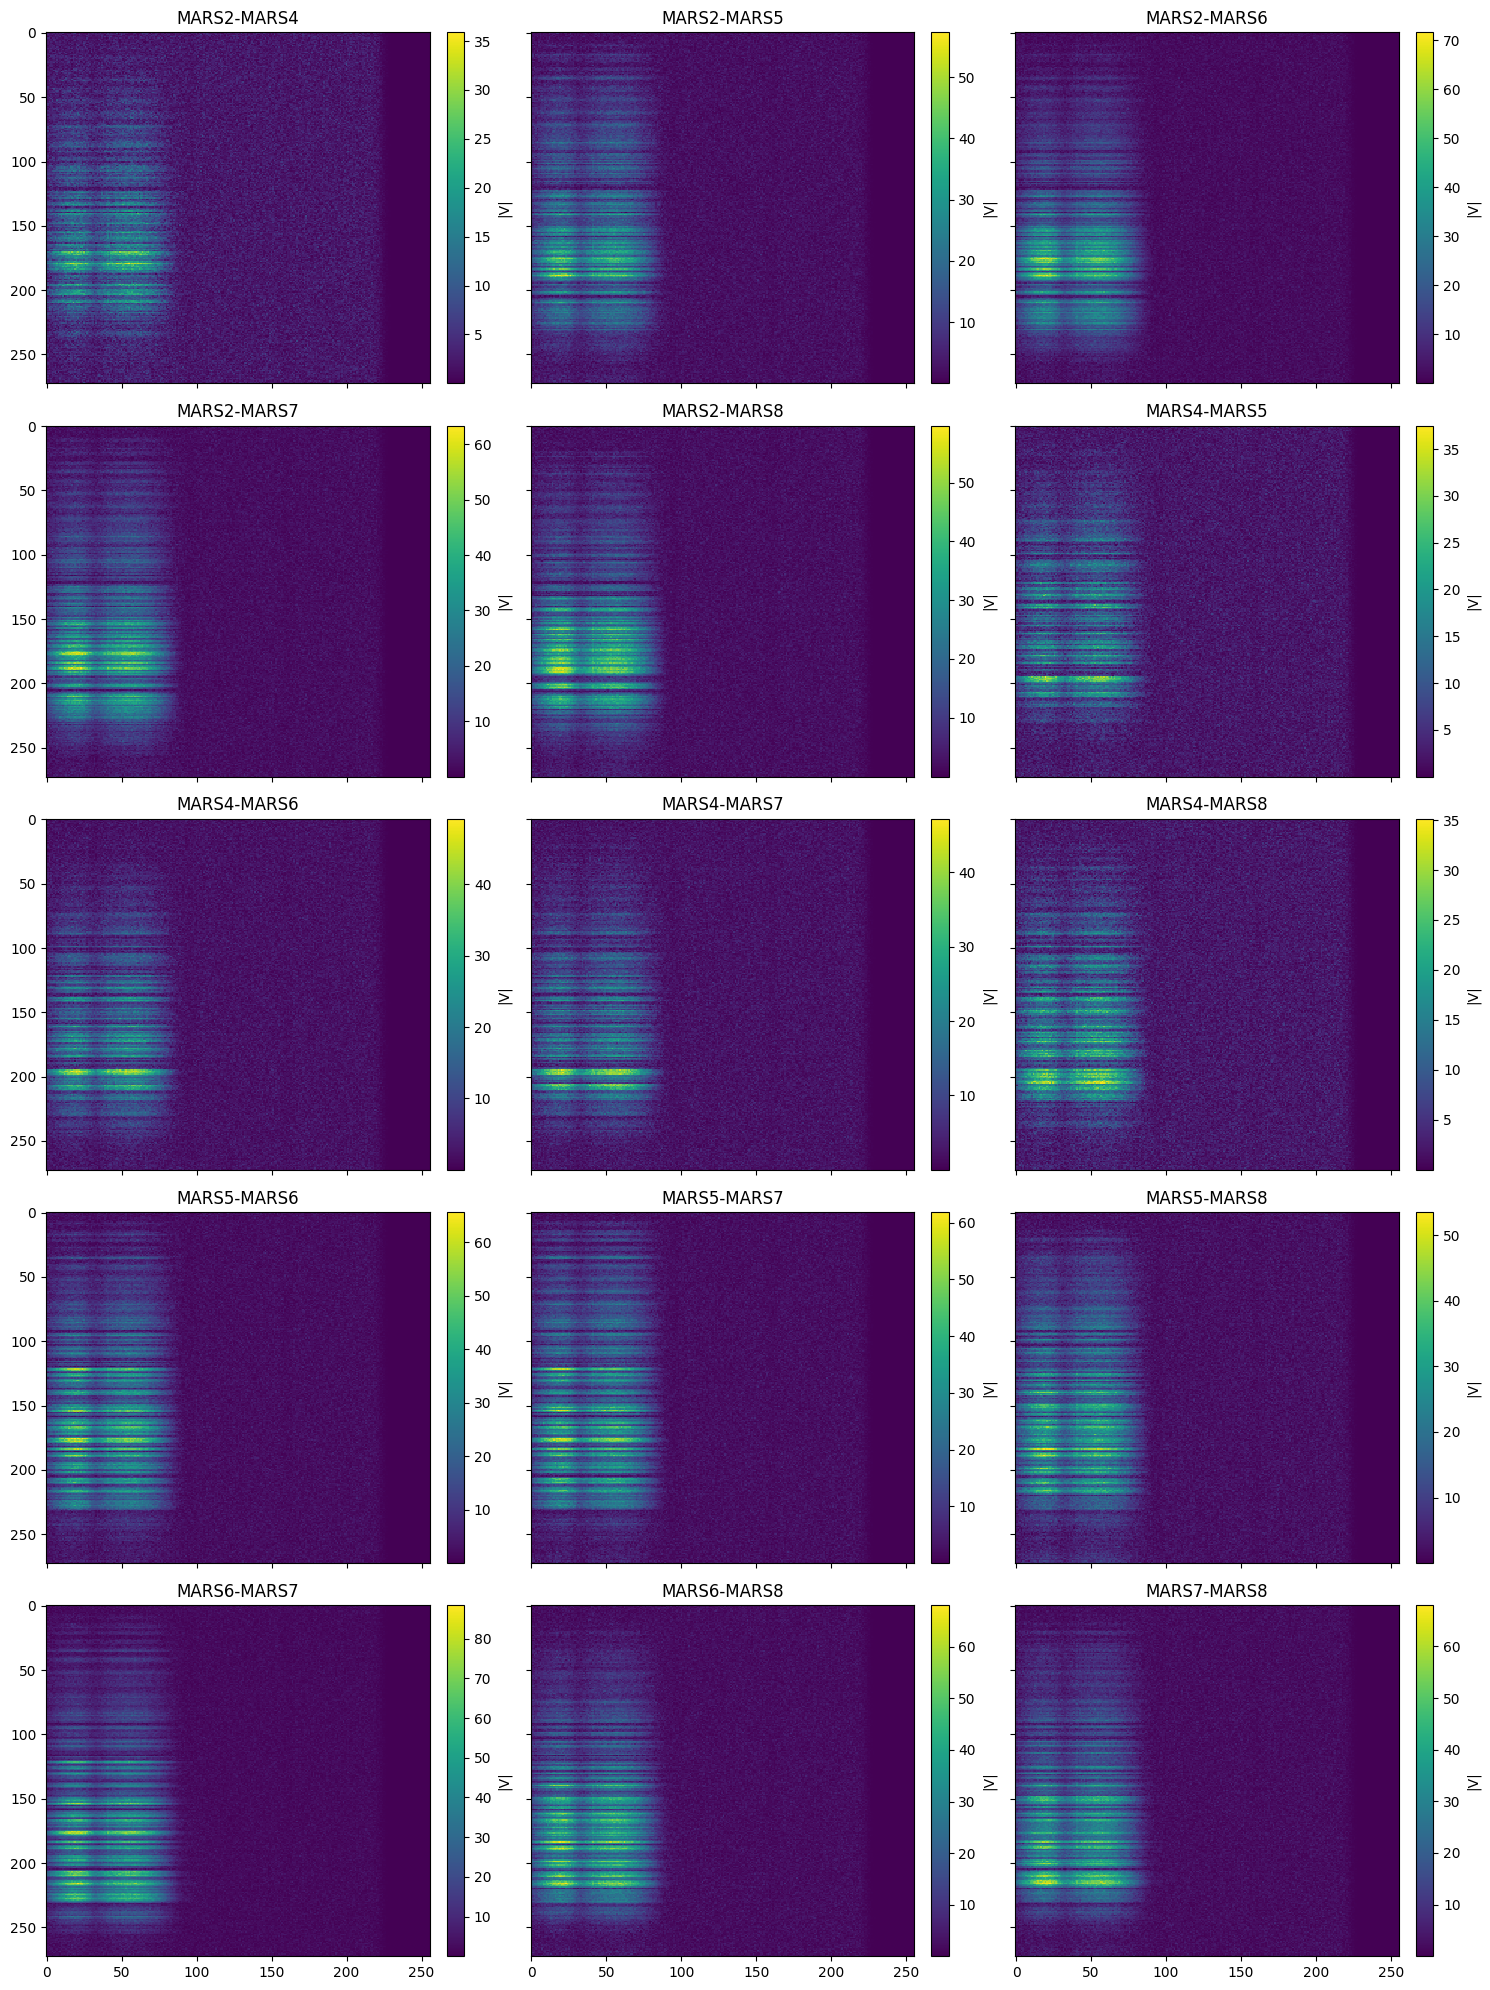

In [ ]:
#plot the amplitude
importlib.reload(futils)
amp_plot = futils.plot_amp(vis1, ant_idxs, antmap)

To isolate for the correct channels, we cut the visibility along the frequency axis

In [ ]:
#cut for channels
chans_new_slice = futils.find_signal_channels(vis1, 'METEOR')
vis1=vis1[:,:,chans_new_slice]

freqs = freqs_all[chans_new_slice]
freqs_normalized = freqs/1e9
nchans = len(freqs)
print(freqs[0])
print(freqs_normalized[0])

137938499.4506836
0.1379384994506836


We now plot the visibility angles, computing the thermal noise (phase ramp noise). As you can see, parts of the pass are quite noisy, so the idea is to cut the pass along time for the contiguous region with lowest noise

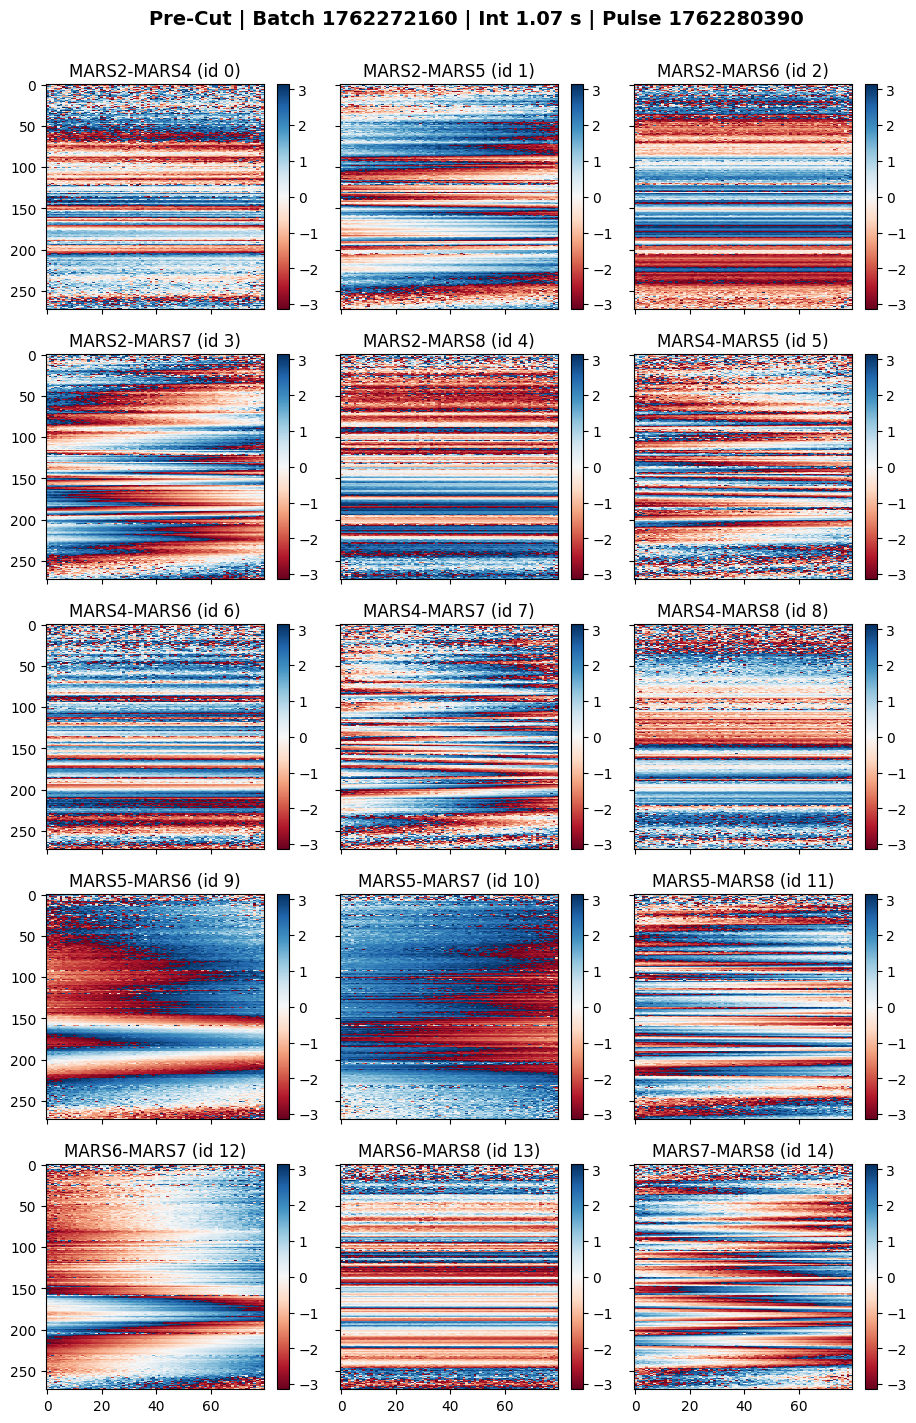

In [ ]:
importlib.reload(futils)
thermal_noise1, fig = futils.get_thermal_noise(vis1, ant_idxs, antmap, title = f'Pre-Cut | Batch {batch_start_ts} | Int {T_SPECTRA*acclen:.2f} s | Pulse {pulse_start_ts}', mask=None, T_SPECTRA = T_SPECTRA, acclen=acclen)

Here we see the phase noise over the entire pass, using all of our visibilities. Some parts suck, so let's cut them out.

(15, 273)


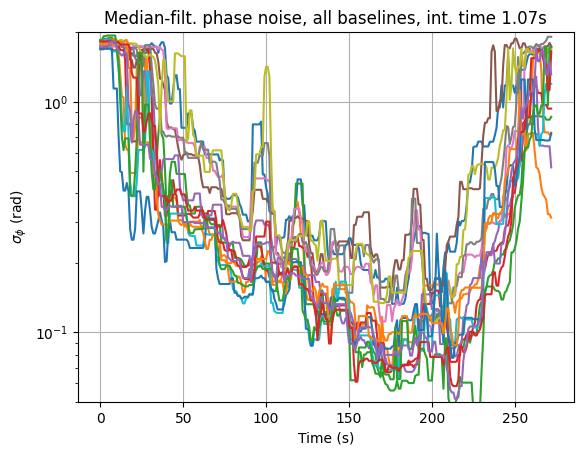

In [ ]:
print(thermal_noise1.shape)
for bl in range(nblines):
    plt.semilogy(median_filter(thermal_noise1[bl,:],10),label=f'bl id {bl}')
plt.title(f"Median-filt. phase noise, all baselines, int. time {T_SPECTRA*acclen:4.2f}s")
plt.ylabel("$\sigma_\phi$ (rad)")
plt.xlabel("Time (s)")
plt.ylim(0.05,2)
plt.grid(True)

We have a very handy code that will cut the phase noise to the cleanest contiguous section of length `window_size`. We have mainly been cutting to the best two minutes or so of signal, as experimentally, this seems the longest continuous period a satellite pass remains at high SNR.

In [ ]:
window_size = int(2**13*3*5/acclen) #want around 2 minutes always
start_cut, end_cut = futils.find_lowest_noise(thermal_noise1, window_size = window_size)

print(start_cut, end_cut)
start_spectra, end_spectra = start_cut*acclen, end_cut*acclen

109 229


We adjust the start and end times according to the cut.

In [ ]:
pulse_start_spec_cut = pulse_start_spec+start_spectra*osamp
pstart2 = UTC_per_spec*pulse_start_spec_cut + UTC_offset
print(pstart2)

vis2 = vis1[:,start_cut:end_cut,:]
print(vis2.shape)
ntimes = end_cut-start_cut

1762280507.2434795
(15, 120, 80)


If we look at the phases now, they look much cleaner, with visibly lower phase noise (as seen below). We now have everything we need to get started on the fitting process.

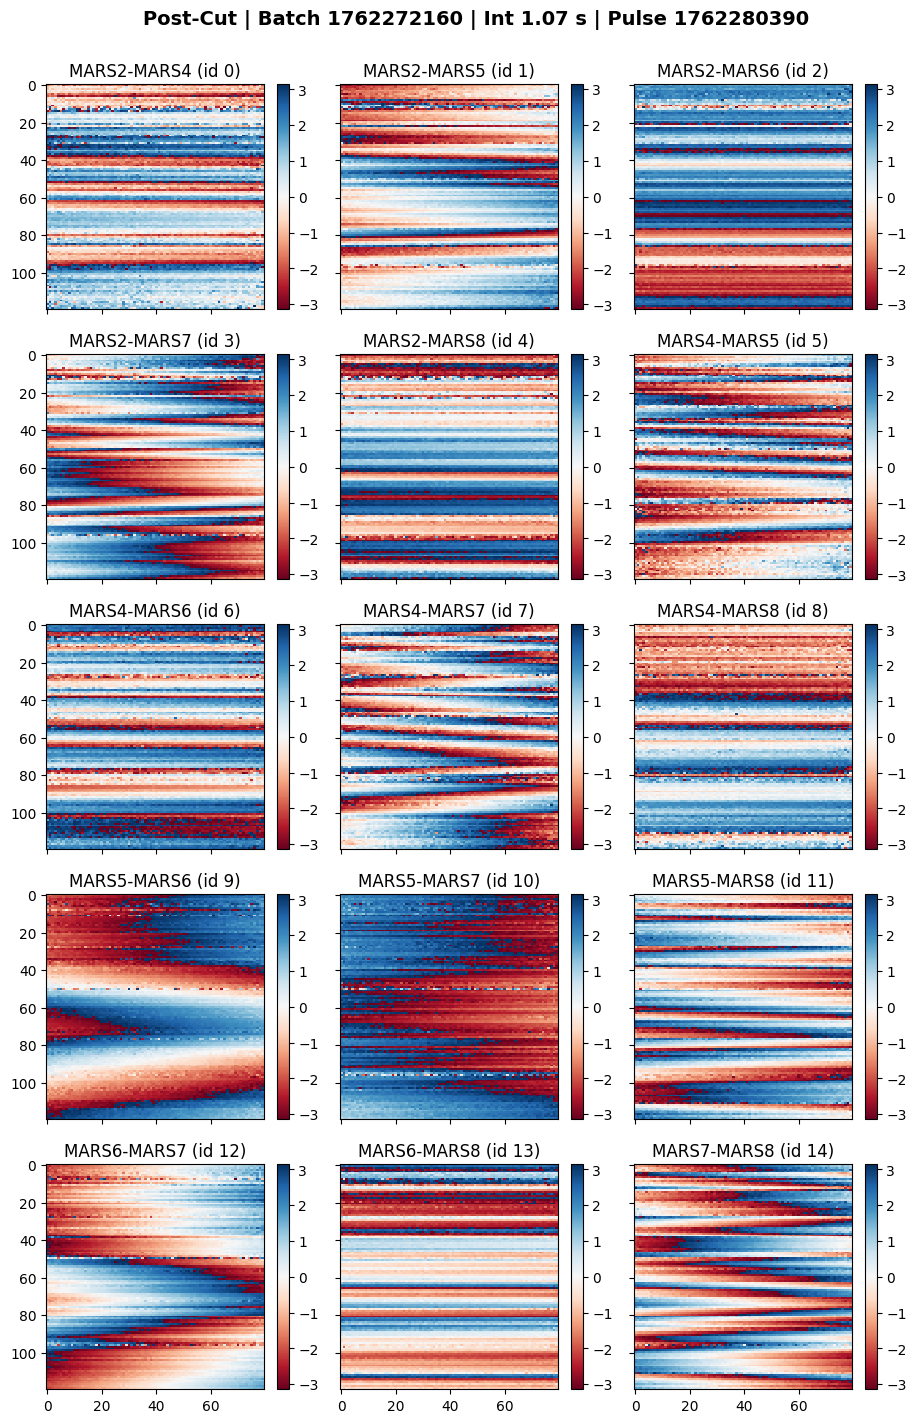

In [ ]:
#plot fully cut pulse, get thermal noise
thermal_noise2, _ = futils.get_thermal_noise(vis2, ant_idxs, antmap, title = f'Post-Cut | Batch {batch_start_ts} | Int {T_SPECTRA*acclen:.2f} s | Pulse {pulse_start_ts}',  mask=None, acclen = acclen)

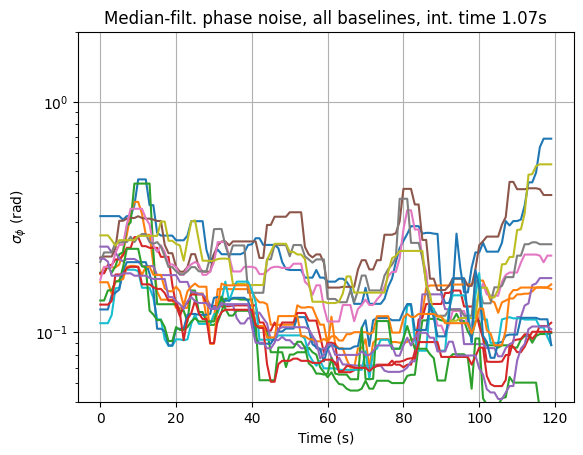

In [ ]:
#plot the thermal noise (smoothed a bit)
for bl in range(nblines):
    plt.semilogy(median_filter(thermal_noise2[bl,:],10),label=f'bl id {bl}')
plt.title(f"Median-filt. phase noise, all baselines, int. time {T_SPECTRA*acclen:4.2f}s")
plt.ylabel("$\sigma_\phi$ (rad)")
plt.xlabel("Time (s)")
plt.ylim(0.05,2)
plt.grid(True)

## 3. Making Guesses
Here we just want to get initial values of tau that will let us get into the good region of the cost surface.

guesses using timestamps from 66 to 71
(15, 80)
(15, 80)


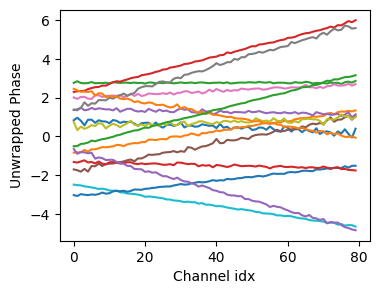

In [ ]:
#find 5 time-sample window with lowest phase noise
start_cut_guess, end_cut_guess = futils.find_lowest_noise(thermal_noise2, window_size = 5)
print(f'guesses using timestamps from {start_cut_guess} to {end_cut_guess}')

#get an initial guess for tau
avg_multi_vis = np.mean(vis2[:, start_cut_guess:end_cut_guess, :], axis=1) #starting position is arbitrary for now. make lowest phase noise region?
nbl = avg_multi_vis.shape[0]
print(avg_multi_vis.shape)

avg_multi_phase = np.unwrap(np.angle(avg_multi_vis), axis = 1)
#avg_multi_phase = avg_multi_phase - avg_multi_phase[:, 39][:, None]
plt.figure(figsize=(4, 3))
for i in range(nbl):
    plt.plot(avg_multi_phase[i,:])
plt.xlabel('Channel idx')
plt.ylabel('Unwrapped Phase')

#get that noise by fitting a line and getting std of residuals
noise_matrix_avg = np.zeros((1,nbl),dtype='float64')
for bl in range(nbl):
    y = avg_multi_phase[bl,:]
    m, c = np.polyfit(freqs,y, 1)
    residual = y - (m*freqs + c)
    noise_matrix_avg[0,bl] = np.std(residual)
# print(noise_matrix_avg)
print(avg_multi_phase.shape)

We now fit on these (noisy) ramps for the guesses on tau

In [ ]:
data_matrix = avg_multi_phase.T.reshape(1,nchans,nbl)
print(data_matrix.shape)

Ag = futils.get_grammian(nant)
AtA2,Atd2 = futils.get_AtA_Atd(data_matrix,
                        Ag,
                        noise_matrix_avg**2,
                        freqs_normalized,
                        nant,
                        nchans,  
                        1,
                        fit_constant=True
                        )

AtA_inv2 = np.linalg.inv(AtA2)
mfit2 = AtA_inv2 @ Atd2

# Total parameters for tau: ntime * (nant-1)
bs = nant - 1
taus_guess0 = mfit2[:1 * bs]
phi_guess0 = mfit2[1 * bs:]
errs_guess0 = np.sqrt(np.diag(AtA_inv2))
print('initial guesses for taus:', taus_guess0)
print('phis', phi_guess0)
print('errors on phi, tau', errs_guess0)

prediction = -2*np.pi*taus_guess0[0]*freqs_normalized
phis_guess0 = np.mean(prediction - avg_multi_phase[0,:])
print(phis_guess0)

(1, 80, 15)
Snu 69.3165171680843 Snu2 60.05974593564144
initial guesses for taus: [-1414.85497648  4540.41238719    40.65323836  7866.77179676
  -691.41138488]
phis [ 1225.25457335 -3937.82711947   -36.94418404 -6819.35593477
   597.42102796]
errors on phi, tau [26.48753525 15.65030854 14.07754657 14.22785359 21.49927456 22.95029644
 13.56031118 12.19758139 12.32781588 18.62818567]
1225.4065631404605


To make sure we're not too far off, we plot the guess ramps against some real data values

15


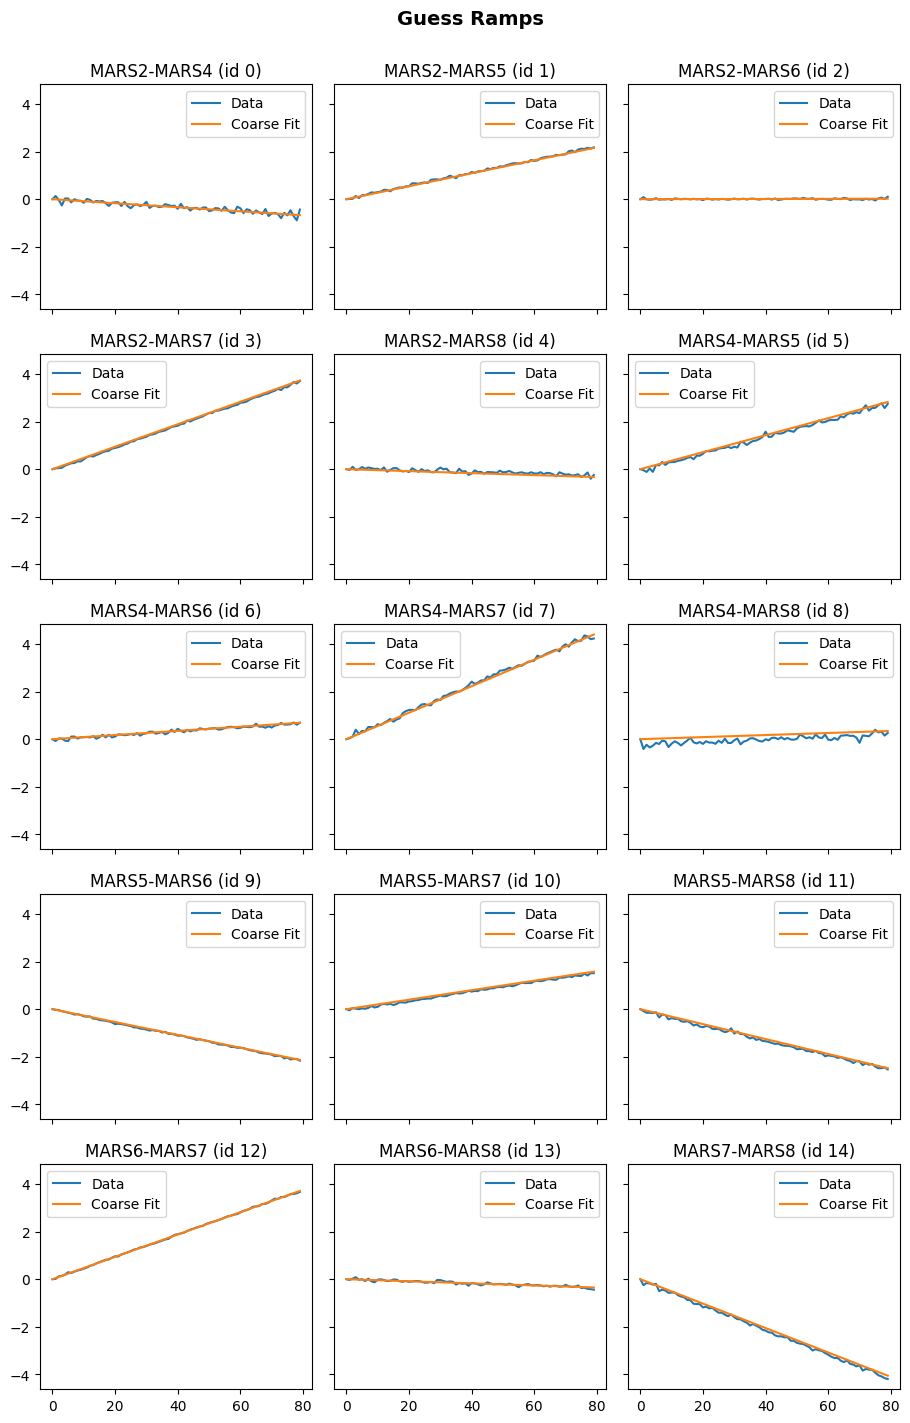

In [ ]:
#plot the ramp guesses vs data

ncols = 3
title = 'Guess Ramps'
nrows = int(np.ceil(nblines / ncols))
fig, ax = plt.subplots(nrows, ncols,figsize=(10, 3*nrows),sharex=True,sharey=True)
fig.subplots_adjust(left=0.07,right=0.93,bottom=0.05,top=0.92,wspace=0.08,hspace=0.20)
fig.text(0.5, 0.97,title,ha="center",va="top",fontsize=14,fontweight="bold")
ax = np.ravel(ax)

blnum=0
print(nblines)
x = np.arange(nchans)
phased_vis = np.empty_like(vis2[:,:,:])
for i in range(len(ant_idxs)):
        for j in range(i+1, len(ant_idxs)):
            ai = ant_idxs[i]
            aj = ant_idxs[j]
            ax[blnum].set_title(f"{antmap[ai]}-{antmap[aj]} (id {blnum})")
            if i==0:
                tau1=0
            else:
                tau1 = taus_guess0[i-1]
            tau2 = taus_guess0[j-1]
            rel_delay = tau1-tau2
            phase_bline = avg_multi_phase[blnum, :]
            phase_pred = np.unwrap(np.angle(np.exp(2j*np.pi*rel_delay*freqs_normalized)))
            ax[blnum].plot(phase_bline - phase_bline[0], label='Data')
            ax[blnum].plot(phase_pred - phase_pred[0], label='Coarse Fit')
            ax[blnum].legend()
            blnum+=1

We set up the data arrays for the tracking fits: angles and weights

noise var shape (15, 120)
data_matrix shape (120, 80, 15)
weight_matrix shape (120, 15)
noise matrix shape (120, 15)
ntimes 120
nchans 80
nblines 15


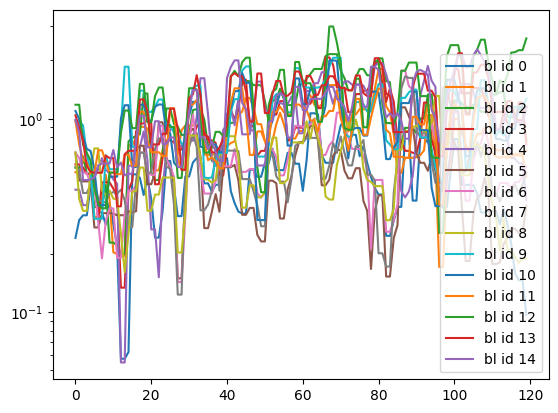

In [ ]:
# get noise and fit for each timestamp. plot the weights
noise_var = median_filter(thermal_noise2[:,:],3,axes=1)**2   #why a median filter of just 3??
print('noise var shape', noise_var.shape)

weights = np.sqrt(np.size(noise_var)/noise_var/np.sum(1/noise_var))
angle = np.angle(vis2)

phase_unwrapped = angle
weight_matrix = weights.T.copy()
for bl in range(nblines):
    plt.semilogy(weights[bl,:],label=f'bl id {bl}')
plt.legend()

#make baseline fastest moving axis for convenience
data_matrix = phase_unwrapped.transpose(1,2,0).copy()
noise_matrix = noise_var.T.copy()
print('data_matrix shape', data_matrix.shape)
print('weight_matrix shape', weight_matrix.shape)
print('noise matrix shape', noise_matrix.shape)

# make frequencies order 1 for fitting purposes
freqs_normalized = freqs.copy()/1e9

# set up some global variables
assert ntimes == data_matrix.shape[0]
assert nchans == data_matrix.shape[1]
assert nblines == data_matrix.shape[2]
assert nant == len(ant_idxs) 
print('ntimes', ntimes)
print('nchans', nchans)
print('nblines', nblines)
#print("nant used:", nant_used)

We plot the cost surface, using the weight matrix and actual data, of the first time sample to see if our guess makes sense. The idea is to get to the peak of the (sinc-modulated cosine) cost surface, and we can actually see if we get close using our guess. It doesn't have to be perfect, it just has to be near the peak where the surface is well-behaved.

(120, 80, 15)
4540.412387192249
4540.412387192249


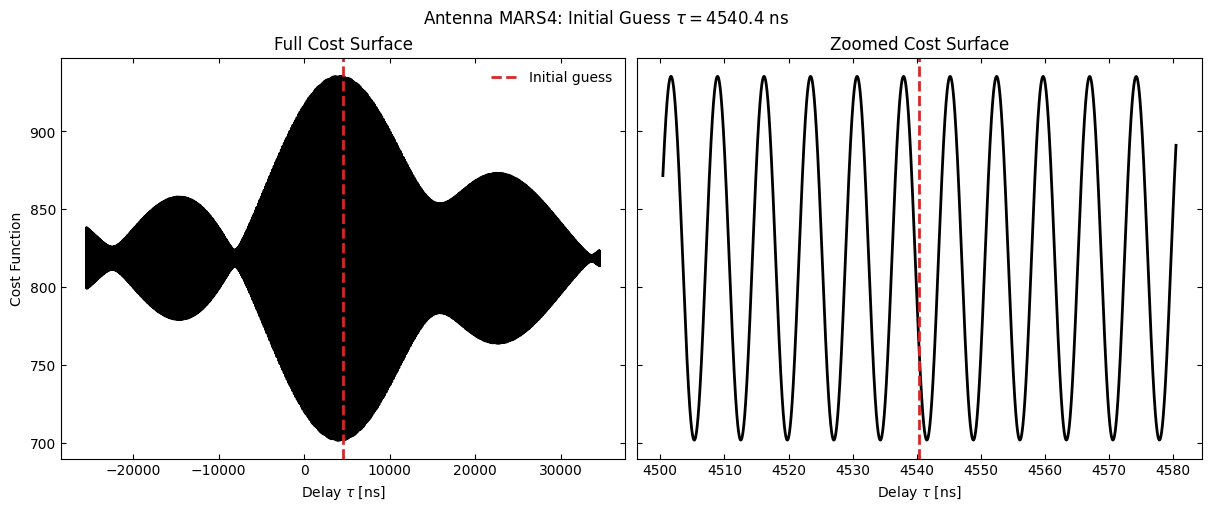

In [ ]:
#check the cost surface to see if it makes sense
cost1, cost2, fig = futils.cost_surface(data_matrix, taus_guess0, freqs_normalized, weight_matrix, antmap, antidx=1, timeidx=0, N1=10001, N2=40)

## 4. Peak Tracking Fit
This is the core of fine timing, where we do a phase tracking fit and get zeroed delays out the other side

starting guess: [-1414.85497648  4540.41238719    40.65323836  7866.77179676
  -691.41138488]
done tt=0, time = 0.323
done tt=1, time = 0.001
done tt=2, time = 0.001
done tt=3, time = 0.001
done tt=4, time = 0.001
done tt=5, time = 0.001
done tt=6, time = 0.001
done tt=7, time = 0.001
done tt=8, time = 0.001
done tt=9, time = 0.001
done tt=10, time = 0.001
done tt=11, time = 0.001
done tt=12, time = 0.002
done tt=13, time = 0.001
done tt=14, time = 0.001
done tt=15, time = 0.001
done tt=16, time = 0.001
done tt=17, time = 0.001
done tt=18, time = 0.001
done tt=19, time = 0.001
done tt=20, time = 0.001
done tt=21, time = 0.001
done tt=22, time = 0.001
done tt=23, time = 0.001
done tt=24, time = 0.001
done tt=25, time = 0.001
done tt=26, time = 0.001
done tt=27, time = 0.001
done tt=28, time = 0.001
done tt=29, time = 0.001
done tt=30, time = 0.001
done tt=31, time = 0.001
done tt=32, time = 0.001
done tt=33, time = 0.001
done tt=34, time = 0.001
done tt=35, time = 0.001
done tt=36, time

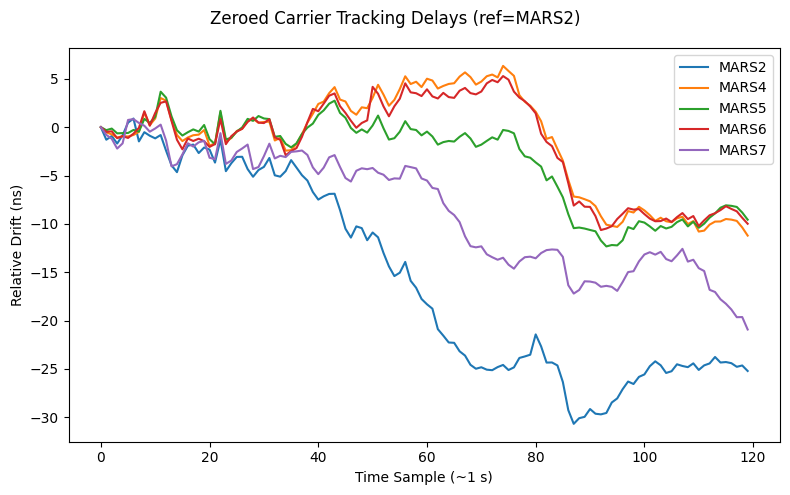

In [ ]:
# array of fitted taus for each time, for each (non-reference) antenna
taus_carrier = np.zeros((ntimes,nant-1),dtype='float64')
taus_carrier_errs = np.zeros_like(taus_carrier)

# make some guess about fitted taus (for one sample time)
taus_guess = taus_guess0
print('starting guess:', taus_guess0)

for tt in range(ntimes):
    ydata = data_matrix[tt,:,:].ravel()
    weights = weight_matrix[tt,:]
    t1=time.time()

    tau_fit_params = least_squares(futils.func, taus_guess, args=(ydata, freqs_normalized, weights),
                                                        jac=futils.jac,
                                                        method='lm',
                                                        ftol=1e-06, 
                                                        xtol=1e-06, 
                                                        gtol=1e-06, 
                                                        loss='linear')

    t2=time.time()
    taus_carrier[tt,:] = tau_fit_params['x']
    taus_guess = tau_fit_params['x']
    #taus_carrier_errs[tt,:] = tau_fit_params['jac']
    
    #print(f"done tt={tt}, time = {t2-t1:5.3f}")

fig, ax = plt.subplots(figsize=(8,5))
tausz_carrier = np.zeros_like(taus_carrier)
for antidx in range(nant-1):
    ts = taus_carrier[:,antidx] - taus_carrier[0,antidx]
    tausz_carrier[:,antidx] = ts
    ax.plot(ts, label=antmap[antidx])
    ax.set_xlabel('Time Sample (~1 s)')
    ax.set_ylabel('Relative Drift (ns)')
ax.legend()
plt.suptitle(f'Zeroed Carrier Tracking Delays (ref={antmap[0]})')
plt.tight_layout()

In [ ]:
max_tau_jump = np.max(np.abs(np.diff(np.concatenate(tausz_carrier, axis=0), axis=0)))
print(max_tau_jump)

30.92672080599914


We can now align the zeroed taus to see the phase ramps stack together. To make the ramps look clearer when plotting, we zero the phase in the center of the frequency bandwidth.

15


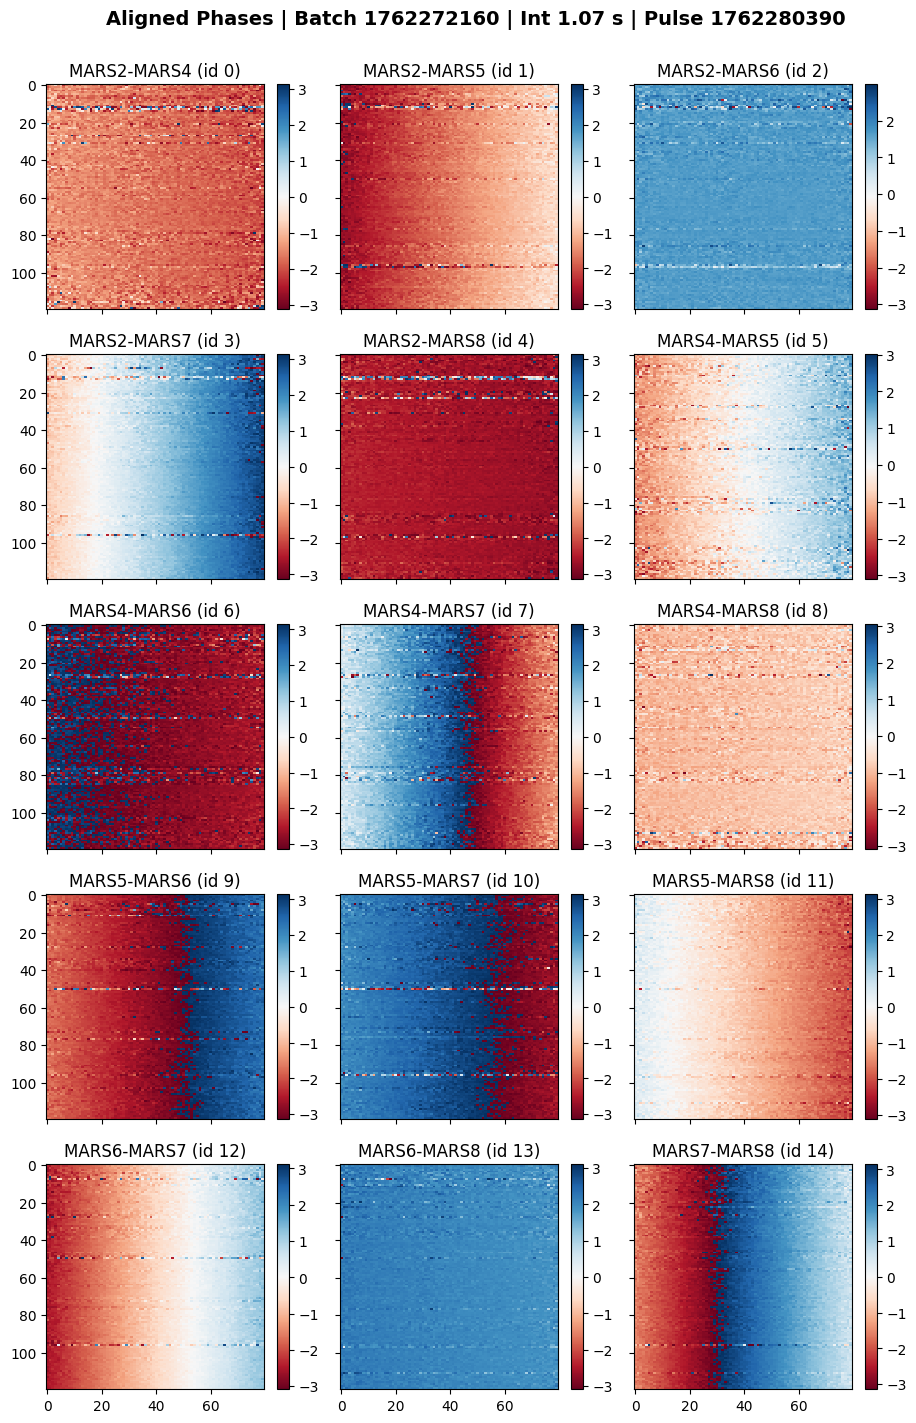

In [ ]:
#generate aligned phase plots for each baseline with fitted taus
#in the meantime also phases the visibilities to align them
title = f'Aligned Phases | Batch {batch_start_ts} | Int {T_SPECTRA*acclen:.2f} s | Pulse {pulse_start_ts}'
ncols = 3
nrows = int(np.ceil(nblines / ncols))
fig, ax = plt.subplots(nrows, ncols,figsize=(10, 3*nrows),sharex=True,sharey=True)
fig.subplots_adjust(left=0.07,right=0.93,bottom=0.05,top=0.92,wspace=0.08,hspace=0.20)
ax = np.ravel(ax)
fig.text(0.5, 0.97,title,ha="center",va="top",fontsize=14,fontweight="bold")

blnum=0
print(nblines)
x = np.arange(nchans)
phased_vis = np.empty_like(vis2[:,:,:])
for i in range(len(ant_idxs)):
        for j in range(i+1, len(ant_idxs)):
            ai = ant_idxs[i]
            aj = ant_idxs[j]
            if i==0:
                tau1=0
            else:
                tau1 = tausz_carrier[:,i-1]
            tau2 = tausz_carrier[:,j-1]
            rel_delay = tau1-tau2
            ax[blnum].set_title(f"{antmap[ai]}-{antmap[aj]} (id {blnum})")
            phased_vis[blnum,:,:] = vis2[blnum,:,:]*np.exp(-2j*np.pi*freqs_normalized[None,:]*rel_delay[:,None])
            #plotting data centered at zero so it looks better
            p = np.unwrap(np.angle(phased_vis[blnum]), axis=1)
            pc = p - p[:, nchans//2, None]
            pc = (pc + np.pi) % (2 * np.pi) - np.pi
            img=ax[blnum].imshow(pc,aspect='auto',interpolation='none',cmap='RdBu')
            cbar=plt.colorbar(img,ax=ax[blnum])
            blnum+=1

## 5. Masking and Stacking
If you take a good look at the phases above, you may notice some streaking along frequency for certain timestamps. This is caused by Radio Frequency Interference (RFI) or a signal drop from the satellite. In either case, it introduces excess noise into our aligned phases, and thus is undesirable. We want to mask it out.

In [ ]:
# MASK OVER THE NOISY REGIONS (along time)
# do this for each baseline independently, want mask shape to be (nbl, ntime). don't need to specify channels
mask_all = np.zeros((nbl, ntimes), dtype = bool)
for blid in range(nbl):
    mask_all[blid, :], _ = rfitools.time_mask(np.abs(phased_vis[blid,:,:]), 1, allow_positive=True)

In [ ]:
triuidx = np.triu_indices(nant, k=1)
print(triuidx[0][0])

0


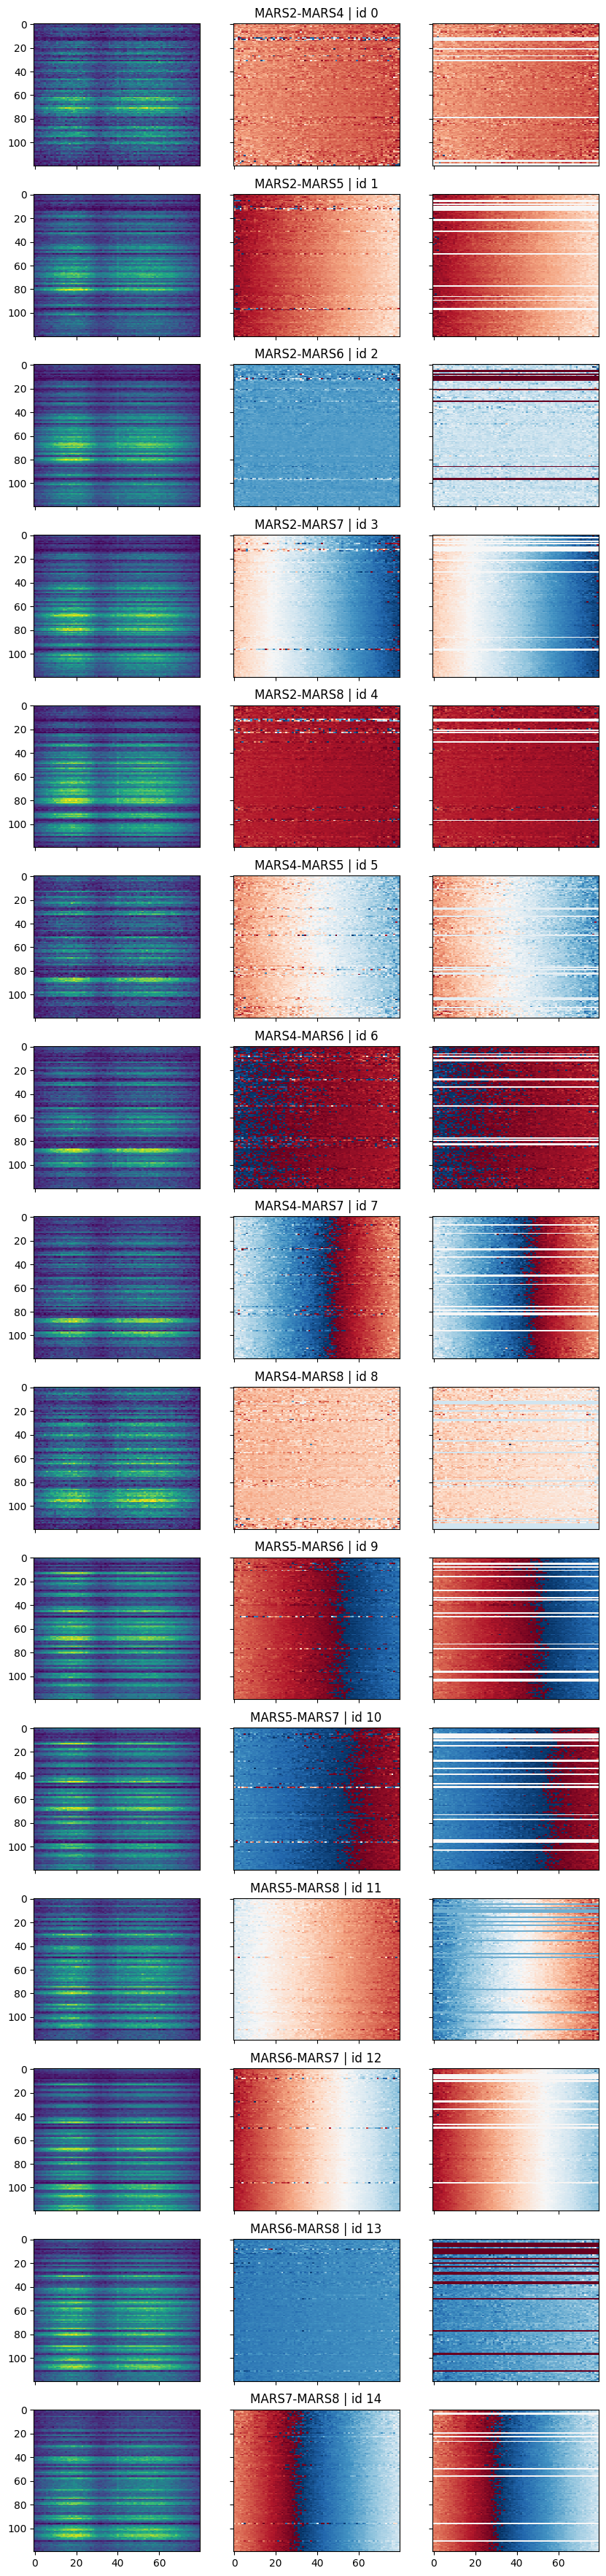

In [ ]:
fig, ax = plt.subplots(nbl, 3, figsize = (10, 3*nbl), sharey=True, sharex=True)
for blid in range(nbl):
    ax[blid, 1].set_title(f'{antmap[triuidx[0][blid]]}-{antmap[triuidx[1][blid]]} | id {blid}')
    im = ax[blid, 0].imshow(np.abs(phased_vis[blid,:,:]), interpolation = 'none', aspect = 'auto')
    im = ax[blid, 1].imshow(np.angle(phased_vis[blid, :, :]),aspect='auto',interpolation='none',cmap='RdBu')
    im = ax[blid, 2].imshow(np.angle(phased_vis[blid, :, :])*(1-mask_all)[blid, :, None],aspect='auto',interpolation='none',cmap='RdBu')

We now average along time to determine the net offset. To see if the masking makes a difference in our stacked ramps, we can plot the masked and unmasked ramps together. 

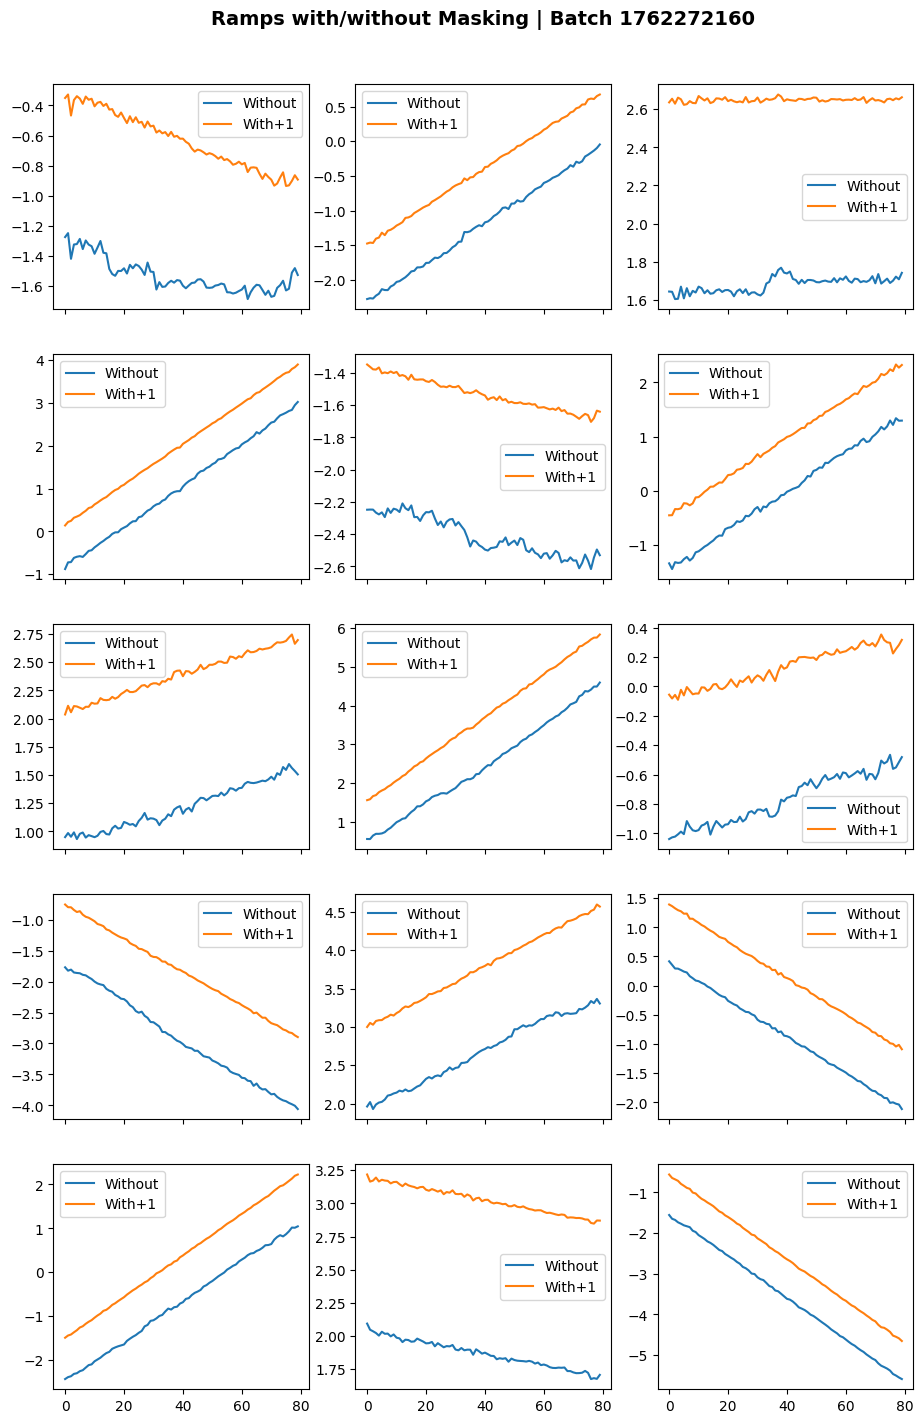

In [ ]:
p = np.unwrap(np.angle(phased_vis), axis=2)
avg_unmasked = np.mean(p, axis=1)
valid = ~mask_all
avg_masked = np.sum(p * valid[:, :, None], axis=1) / np.sum(valid, axis=1)[:, None]

ncols = 3
nrows = int(np.ceil(nbl / ncols))
fig, ax = plt.subplots(nrows, ncols,figsize=(10, 3*nrows),sharex=True)
fig.subplots_adjust(left=0.07,right=0.93,bottom=0.05,top=0.92,wspace=0.18,hspace=0.20)
ax = np.ravel(ax)
fig.text(
    0.5, 0.97,
    f'Ramps with/without Masking | Batch {batch_start_ts}',
    ha="center",
    va="top",
    fontsize=14,
    fontweight="bold"
)
for blid in range(nbl):
    ax[blid].plot(avg_unmasked[blid, :], label='Without')
    ax[blid].plot(avg_masked[blid, :]+1, label='With+1')
    ax[blid].legend()

We now average over time to reduce noise, boost SNR, and get a more accurate single line fit. This gives us the actual true group delay, on top of which the zeroes taus are riding. For each baseline we can plot the ramp and estimate the noise

(80, 15)
[[0.02778669 0.0133971  0.00990466 0.00993292 0.01358888 0.02381823
  0.01868235 0.02178896 0.02811289 0.01149685 0.01334429 0.01400289
  0.00798653 0.00945029 0.01072418]]


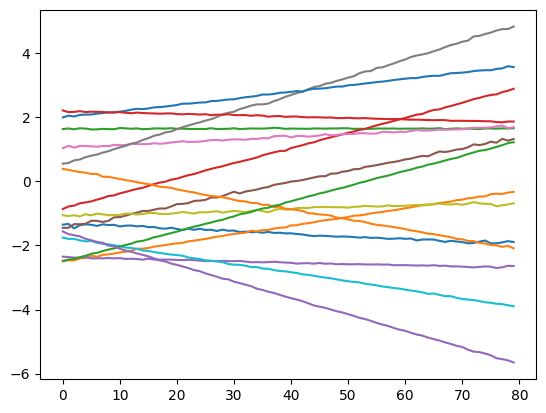

In [ ]:
#take average across time once aligned to boost SNR
avg_multi_vis = avg_masked.T.copy()
#plt.plot(avg_multi_vis)
print(avg_multi_vis.shape)
#get that noise by fitting a line and getting std of residuals
noise_matrix_avg = np.zeros((1,nblines),dtype='float64')

for bl in range(nblines):
    y = avg_multi_vis[:, bl]
    m, c = np.polyfit(freqs,y, 1)
    residual = y - (m*freqs + c)
    noise_matrix_avg[0,bl] = np.std(residual)
print(noise_matrix_avg)
#plt.plot(freqs_normalized[:24], m*freqs_normalized[:24] + c)

In [ ]:
myramp = avg_multi_vis[:,1]
m, c = np.polyfit(freqs, myramp, 1)
print(m, c)

-2.8815163834805105e-05 3972.2359993816644


We now perform a joint OLS fit on the ramps, and get our net tau0s

In [ ]:
#can now just fit linearly using normal equations

data_matrix_stacked = avg_multi_vis
data_matrix_stacked = data_matrix_stacked.reshape(1,nchans,nblines)
print(data_matrix_stacked.shape)

Ag = futils.get_grammian(nant)
print(data_matrix_stacked.shape)

AtA2,Atd2 = futils.get_AtA_Atd(data_matrix_stacked,
                            Ag,
                            noise_matrix_avg**2,
                            freqs_normalized,
                            nant,
                            nchans,
                            1, #ntimes
                            fit_constant=True)

AtA_inv2 = np.linalg.inv(AtA2)

mfit2 = AtA_inv2 @ Atd2
print(mfit2)

# Total parameters for tau: ntime * (nant-1)
bs = nant - 1
tau0_carrier = mfit2[:1 * bs]
phi0_carrier = mfit2[1 * bs:]
errs_all = np.sqrt(np.diag(AtA_inv2))
tau0_carrier_errs = errs_all[:nant-1]

print('net offsets\n', tau0_carrier)
print('errors all\n', errs_all)

(1, 80, 15)
(1, 80, 15)
Snu 69.3165171680843 Snu2 60.05974593564144
[-1362.18775669  4552.75353193    25.85797119  7896.06961185
  -682.54558012  1181.32636338 -3944.80831993   -22.23423102
 -6842.60146716   592.09750485]
net offsets
 [-1362.18775669  4552.75353193    25.85797119  7896.06961185
  -682.54558012]
errors all
 [9.2315044  6.19178947 5.19880405 5.29174873 5.89900961 7.99869677
 5.36491608 4.50453744 4.58506995 5.11123508]


To see if our results make any sense, we can plot the cost surface, for the first timestamp, using our solved initial delay. The grey region gives the three sigma error on the peak position.

(120, 80, 15)
-1362.1877566874027
-1362.1877566874027


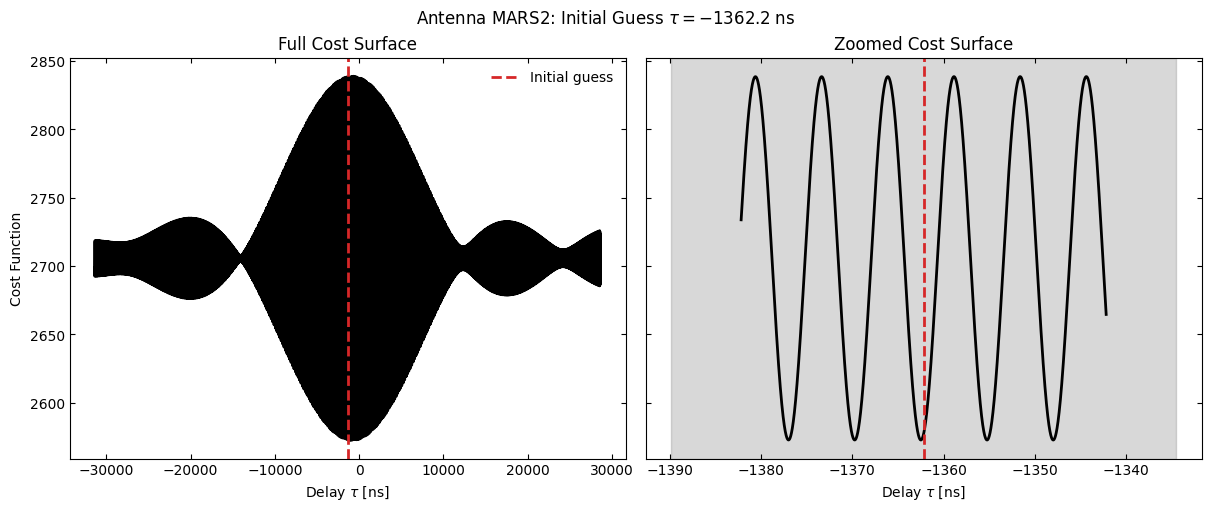

In [ ]:
wts = np.ones([ntimes])
threesigma = errs_all[0]*3
#check that we are on the correct carrier peak
cost1, cost2, fig = futils.cost_surface(data_matrix, tau0_carrier, freqs_normalized, wts, antmap, antidx = 0, timeidx=0, N1=10001, N2=20, err=threesigma)
fig.savefig('./images/cost_surface.png')

In [ ]:
tau0_carrier.shape

(5,)

In [ ]:
tausz_carrier.shape

(120, 5)

In [ ]:
taus = tausz_carrier.T + tau0_carrier[:, None]

## Further Notes
